# Demystifying Model Behavior: From Genetic Risk to Binary Classification

Welcome to this interactive notebook! In this space, we are going to explore exactly how machine learning models and explainability tools behave when we shift the underlying "ground truth" of categorical data predicting a categorical outcome. 

In the real world of clinical genomics and bioinformatics, we often feed discrete data (like genotypes coded as 0, 1, and 2) into an algorithm like XGBoost to predict a **binary outcome**—such as whether a patient has a specific disease or not (coded as 1 or 0). But how do we know *what* the model is actually learning? To answer this, we are going to play the role of the "Creator." We will generate synthetic datasets where **we know the exact biological and probabilistic mechanisms** governing the binary target ($y$). 

By knowing the absolute, indisputable truth, we can test how well Traditional Statistics (Chi-Square & Logistic Regression) and Machine Learning (XGBoost Classifier + SHAP) uncover that truth across three increasingly realistic clinical scenarios.

## The Three Scenarios We Will Explore

We will run an end-to-end analytical pipeline—training, evaluating, and explaining—on the following three cases:

### Case 1: The Simple Logistic World (Pure Main Effects)
* **The Reality:** The binary target $y$ (Disease vs. Healthy) is driven by independent genes acting alone. These genes increase or decrease the hidden "latent risk" (log-odds) of the disease. This risk is then converted into a probability using a sigmoid function, and nature rolls the dice (a binomial distribution) to assign the final 0 or 1.
* **The Goal:** Establish a baseline. We will see how perfectly traditional methods handle simple categorical-to-categorical relationships. We will test if a simple bivariate test (Chi-Square) flags the right genes, how multivariate Logistic Regression captures the true log-odds weights, and how XGBoost + SHAP represent main effects in a probability space.

### Case 2: The Complex Biological World (Epistatic Interactions)
* **The Reality:** Biology is rarely strictly independent; features now interact with one another to influence the log-odds of the disease (e.g., Gene A only increases disease risk if Gene B is also mutated, known as epistasis). 
* **The Goal:** Observe the divergence between traditional stats and machine learning. A standard Chi-Square test evaluates genes one by one and might miss interacting pairs, while Logistic Regression will struggle without manual interaction terms. Conversely, XGBoost's tree structure will naturally map the combinations. We will use SHAP interaction values to crack open the model and visualize exactly how these genes are working together.

### Case 3: The Incomplete World (Missing Heritability / Hidden Features)
* **The Reality:** We generate a complex dataset with interactions, but deliberately *hide* critical contributing genes or environmental factors from the model. 
* **The Goal:** Mimic messy, real-world clinical scenarios where we simply lack all the necessary data. We will watch our classification evaluation metrics (like Accuracy, ROC AUC, and Log Loss) degrade, and use SHAP to see how the model tries (and often fails) to compensate for the missing puzzle pieces.

## Our Toolkit
To accomplish this, we will be utilizing:
* **Custom Generators:** `numpy` and `pandas` to build the exact latent log-odds equations, apply sigmoid probabilities, and sample categorical binomial outcomes.
* **Baseline Modeling:** `scipy.stats` (Chi-Square) for bivariate independence testing, and `statsmodels` (Logistic Regression) for traditional multivariate statistical significance.
* **Predictive Modeling:** `xgboost` (XGBClassifier) to natively handle categorical data and capture non-linear step functions and complex interactions for binary targets.
* **Explainability:** `shap` (SHapley Additive exPlanations) to trace global feature importance, visualize specific biological distributions in log-odds space via violin plots, and isolate pure variable interactions.

In [1]:
from XAI_test_3 import *

## simple linear combination test

### make example data 1

In [2]:

# 1. Generate Binary Data
X, _, y_binary, visible_features, _ = generate_synthetic_classification_data(
    num_inputs=10, 
    num_samples=5000, 
    probability_range=(0.01, 0.49),
    num_contributing_features=(3, 5), 
    num_hidden_features=(0, 0), 
    weight_range=(-1.5, 1.5), 
    num_interactions=(0, 0), 
    interaction_weight_range=(-1.5, 1.5), 
    noise_std=0.5, 
    hidden_in_linear=False,           
    hidden_in_interactions=False,
)

X_train, X_test, y_train, y_test = train_test_split(X, y_binary, test_size=0.2, random_state=42)


--- Generative Model Info (Log-Odds Formulation) ---
Log-Odds (z) = 
  (-1.33 * Feature_3 [dominant]) + 
  (-1.26 * Feature_8 [dominant]) + 
  (-1.03 * Feature_7 [additive]) + 
  (0.74 * Feature_1 [additive]) + 
  (0.18 * Feature_0 [dominant]) 
  + Noise(0, 0.5)
Probability (P) = 1 / (1 + e^-z)
Class Output = Binomial(1, P)



### make the Traditional Baselines 

#### Chi-Square Test


--- Traditional Baseline 1: Chi-Square Independence Tests ---
Significant Features (p < 0.05) [Bivariate Test]:
  - Feature_7: p-value = 2.4571e-82
  - Feature_8: p-value = 3.9276e-34
  - Feature_3: p-value = 5.4586e-34
  - Feature_1: p-value = 5.8077e-27
  - Feature_0: p-value = 3.8609e-06
  - Feature_2: p-value = 2.2189e-02


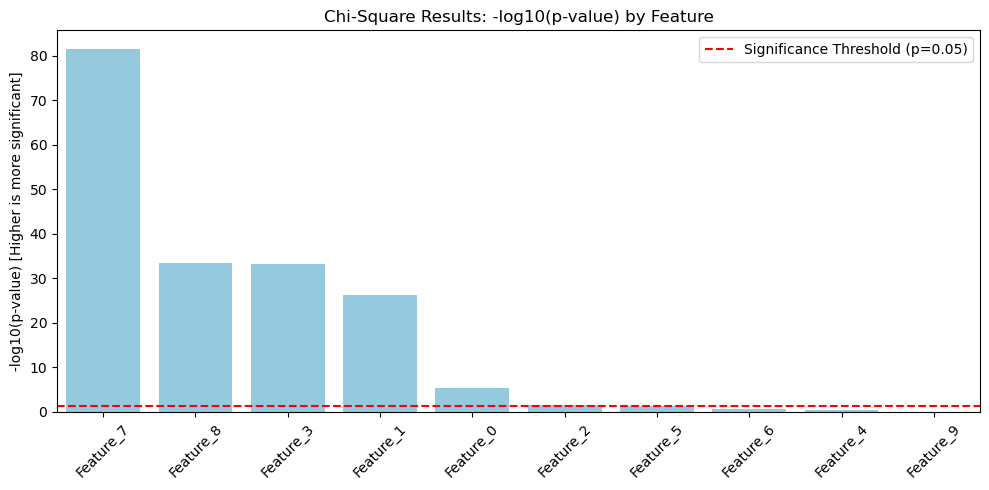

Chi-Square Significant Features: [('Feature_7', 2.457109962489505e-82), ('Feature_8', 3.927624954559847e-34), ('Feature_3', 5.458579241065917e-34), ('Feature_1', 5.8076668718897435e-27), ('Feature_0', 3.8609118610319114e-06), ('Feature_2', 0.02218901779279431), ('Feature_5', 0.05817297120262505), ('Feature_6', 0.24688940606927937), ('Feature_4', 0.38231831416081624), ('Feature_9', 0.9565094610158917)]


In [3]:

# 2a. Traditional Baseline 1 (Chi-Square Test)
chi_square_features = perform_traditional_chi_square(X_train, y_train)

print("Chi-Square Significant Features:", chi_square_features)


#### Logistic Regression


--- Traditional Baseline 2: Multivariate Logistic Regression ---
                           Logit Regression Results                           
Dep. Variable:                      y   No. Observations:                 4000
Model:                          Logit   Df Residuals:                     3989
Method:                           MLE   Df Model:                           10
Date:                Sun, 12 Apr 2026   Pseudo R-squ.:                  0.1746
Time:                        16:55:12   Log-Likelihood:                -2155.1
converged:                       True   LL-Null:                       -2610.8
Covariance Type:            nonrobust   LLR p-value:                2.175e-189
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.1059      0.079      1.340      0.180      -0.049       0.261
Feature_0      0.2495      0.054      4.594      0.000       0.14

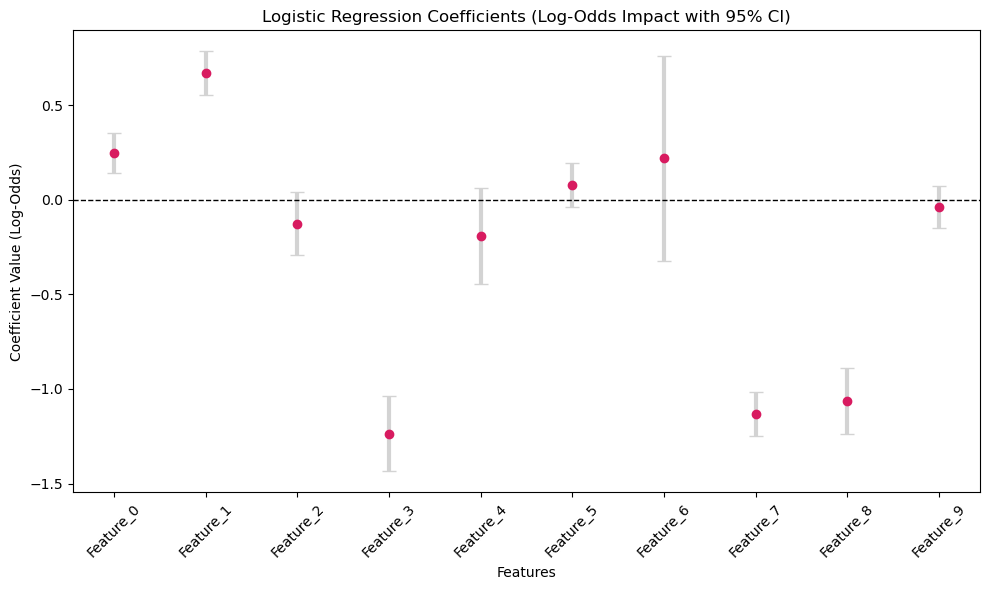

Logistic Regression Significant Features: ['Feature_0', 'Feature_1', 'Feature_3', 'Feature_7', 'Feature_8']


In [4]:

# 2b. Traditional Baseline 2 (Logistic Regression)
logistic_model, logistic_features = perform_traditional_logistic_regression(X_train, y_train)

print("Logistic Regression Significant Features:", logistic_features)


### make a simple xgboost model for test 1

In [5]:

# 3. Categorical Conversion for XGBoost
X_train_cat = X_train.astype('category')
X_test_cat = X_test.astype('category')

# 4. Machine Learning Modeling (XGBoost Classifier)
model = xgb.XGBClassifier(
    n_estimators=100, 
    max_depth=4, 
    learning_rate=0.1,
    enable_categorical=True,
    tree_method='hist',
    objective='binary:logistic',
    random_state=42
)
model.fit(X_train_cat, y_train)

# 5.1. Evaluation
evaluate_xgb_classifier(model, X_test_cat, y_test)



--- XGBoost Classifier Performance (Testing) ---
Accuracy: 0.6910
ROC AUC:  0.7239
Log Loss: 0.5803



### look at XGBoost Native Importances

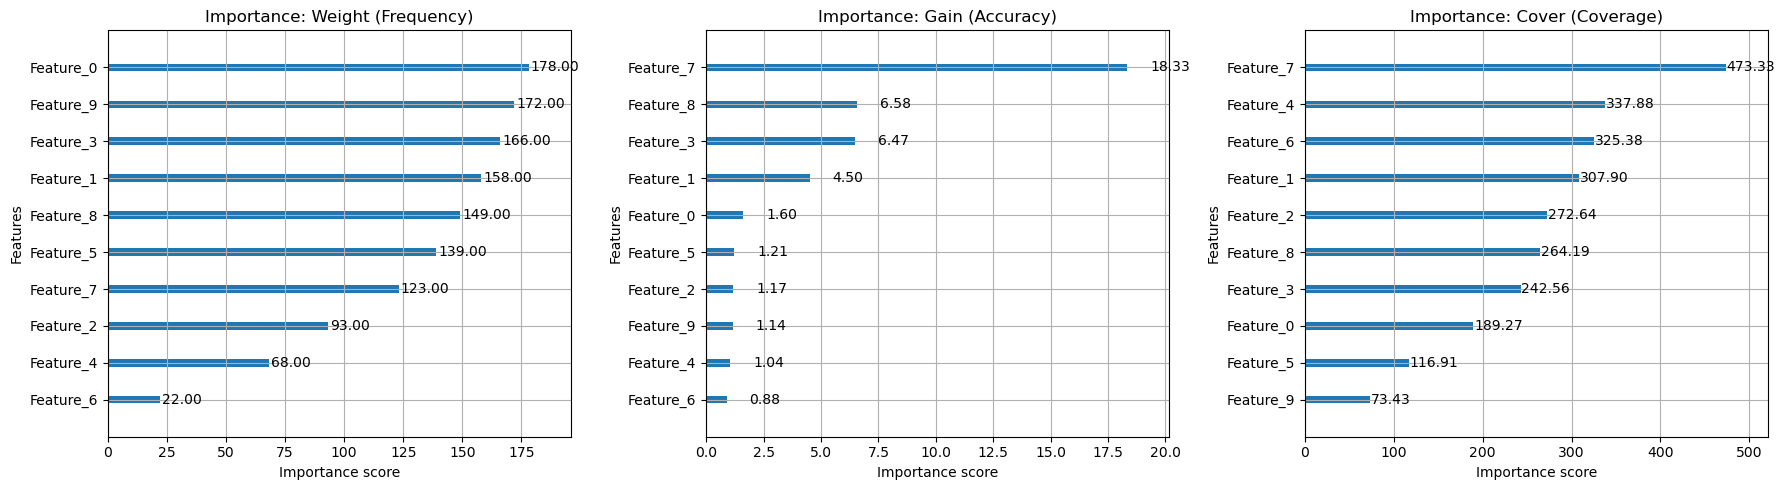

XGBoost Weight Importance: {'Feature_0': 178.0, 'Feature_1': 158.0, 'Feature_2': 93.0, 'Feature_3': 166.0, 'Feature_4': 68.0, 'Feature_5': 139.0, 'Feature_6': 22.0, 'Feature_7': 123.0, 'Feature_8': 149.0, 'Feature_9': 172.0}
XGBoost Gain Importance: {'Feature_0': 1.6040124893188477, 'Feature_1': 4.501219749450684, 'Feature_2': 1.1696776151657104, 'Feature_3': 6.4656782150268555, 'Feature_4': 1.0367196798324585, 'Feature_5': 1.2134506702423096, 'Feature_6': 0.8809748291969299, 'Feature_7': 18.332054138183594, 'Feature_8': 6.583033561706543, 'Feature_9': 1.1425527334213257}
XGBoost Cover Importance: {'Feature_0': 189.26666259765625, 'Feature_1': 307.8976135253906, 'Feature_2': 272.636962890625, 'Feature_3': 242.55694580078125, 'Feature_4': 337.8792724609375, 'Feature_5': 116.91326141357422, 'Feature_6': 325.3836669921875, 'Feature_7': 473.32635498046875, 'Feature_8': 264.1896057128906, 'Feature_9': 73.43030548095703}


In [6]:

# 5.2. XGBoost Importances
weight_importance, gain_importance, cover_importance = plot_all_xgb_importances(model)

print("XGBoost Weight Importance:", weight_importance)
print("XGBoost Gain Importance:", gain_importance)
print("XGBoost Cover Importance:", cover_importance)


### try to use SHAP to find the influencing inputs

In [7]:

# 6. SHAP Explainability 
print("Computing SHAP values...")
explainer = shap.TreeExplainer(model)
shap_values = explainer(X_test_cat)


Computing SHAP values...


#### individual SHAP features ranking

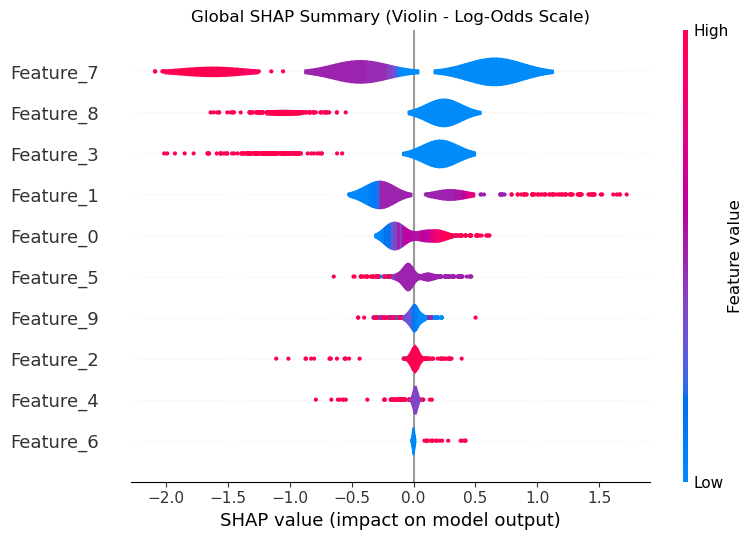

In [8]:

# Global SHAP Violin Summary
plt.title("Global SHAP Summary (Violin - Log-Odds Scale)")
shap.summary_plot(shap_values.values, X_test_cat.astype(float), plot_type="violin", show=False)
plt.show()


Generating SHAP violin grid for all features...


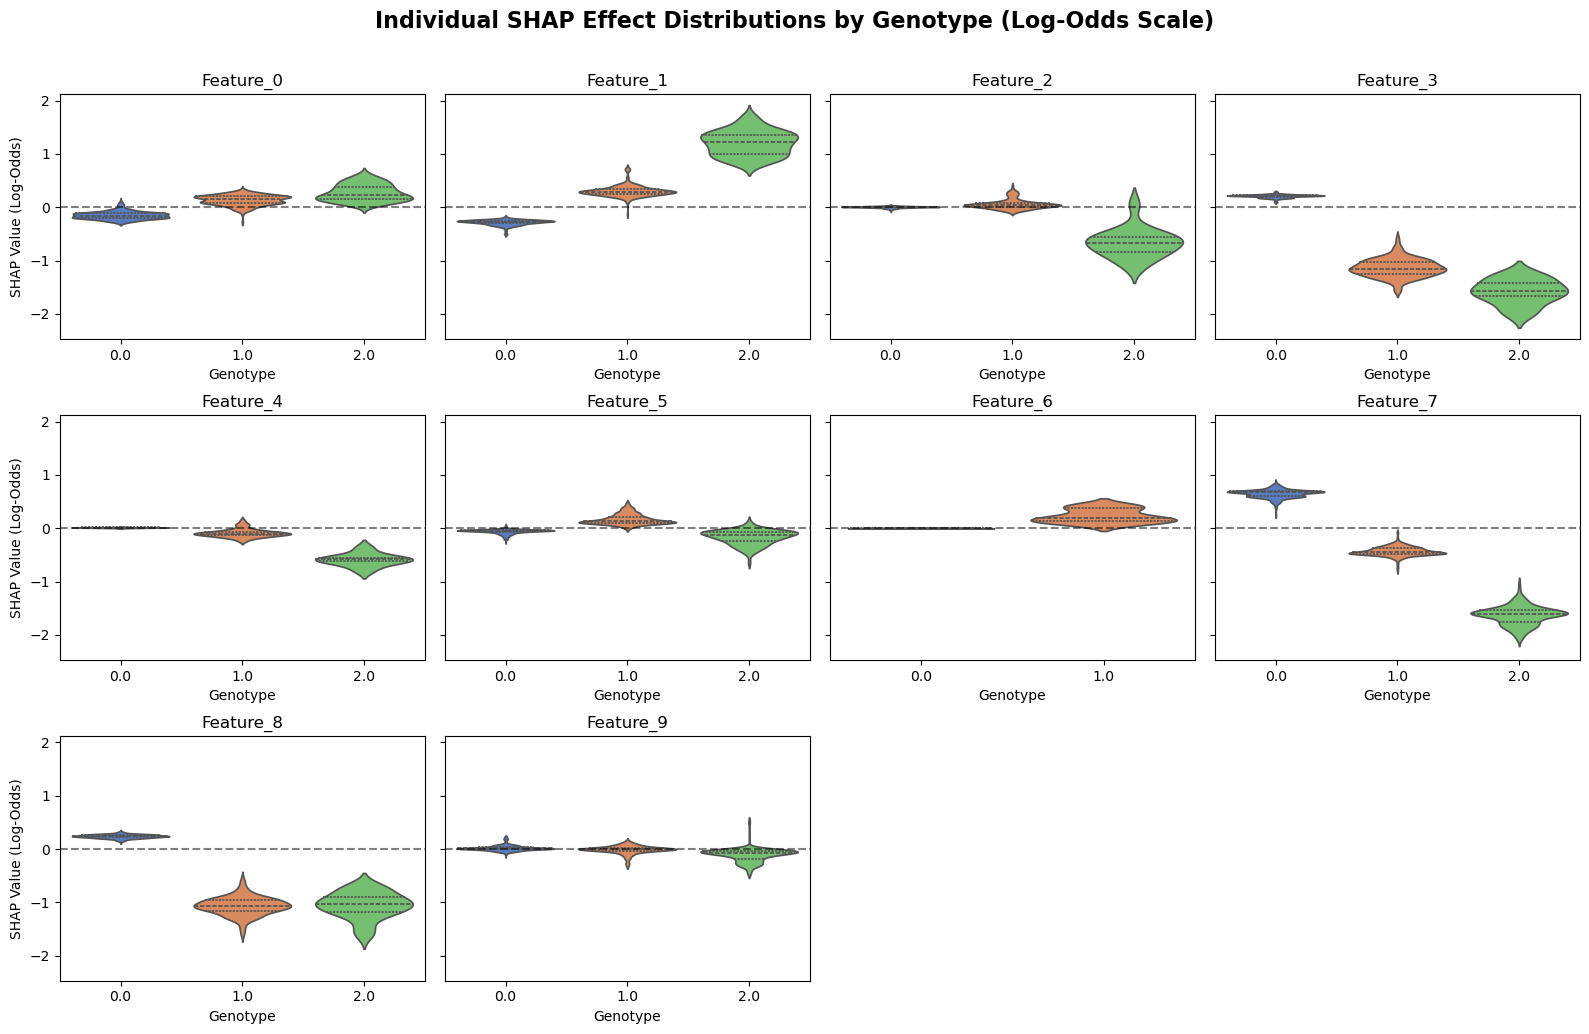

In [9]:

# 7. Individual Feature Violin Plots 
print("Generating SHAP violin grid for all features...")
plot_all_individual_shap_violins(shap_values, X_test_cat, visible_features)


#### try to look for feature interactions
we shouldn't see any


--- Computing SHAP Interaction Values ---


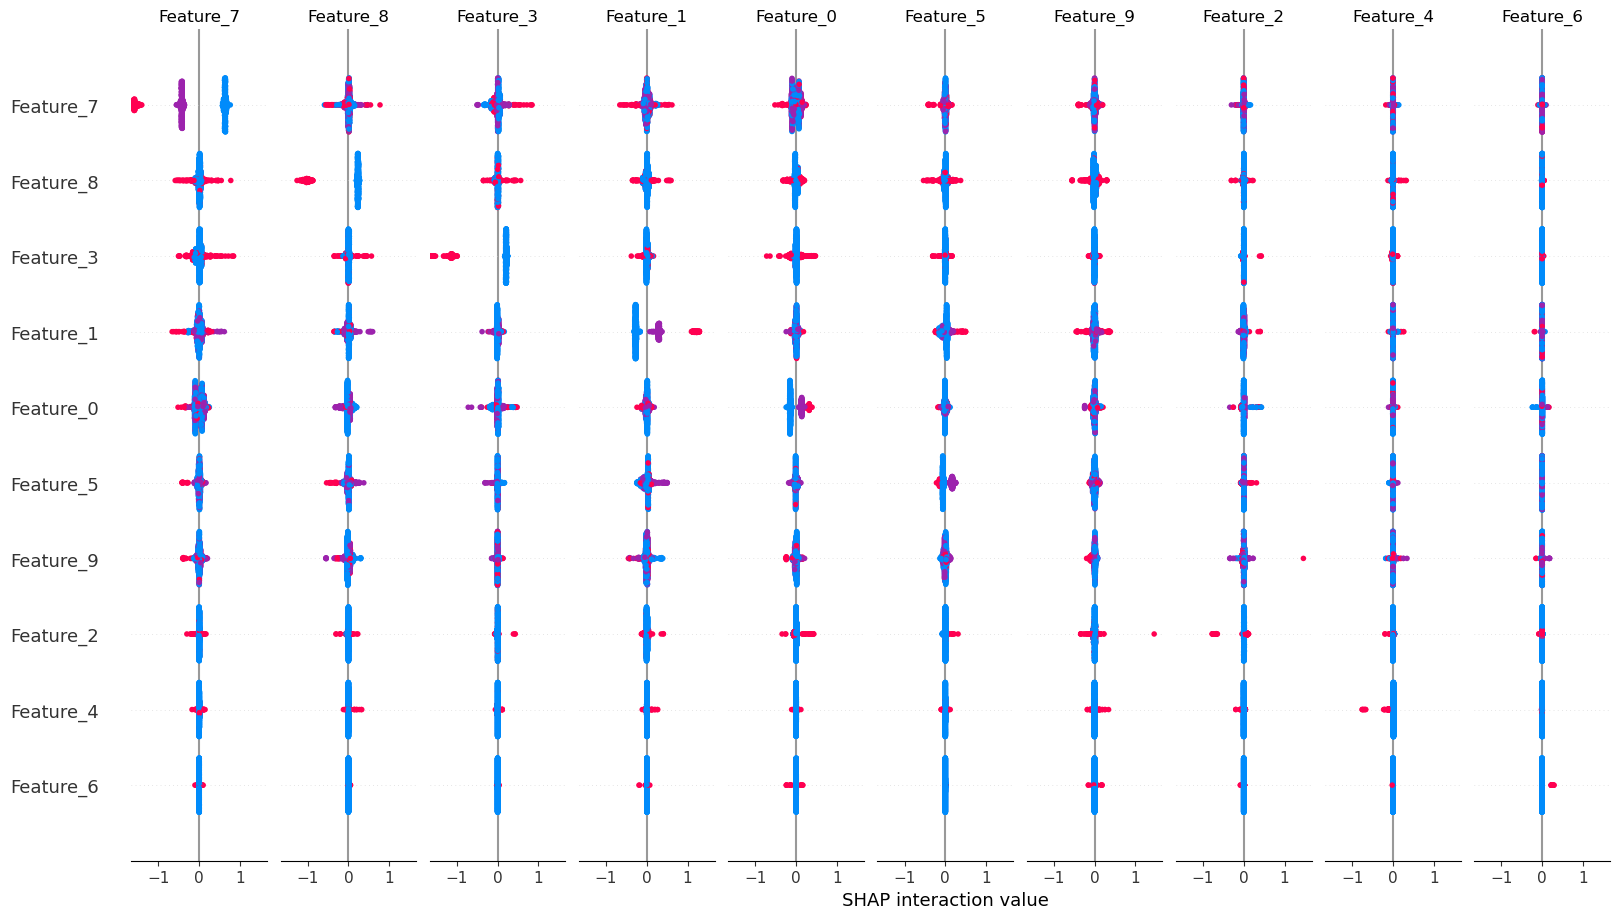


Strongest Interaction found by SHAP: Feature_0 & Feature_7
Plotting pure interaction effect for Feature_0 and Feature_7...


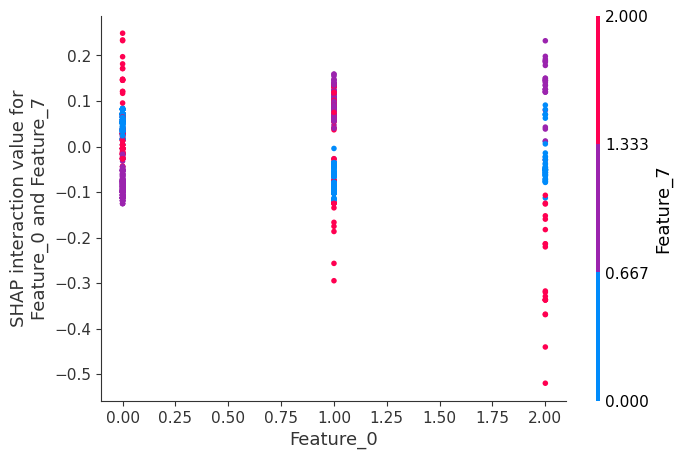


--- SHAP Interaction Feature Importance Ranking ---
Top 10 Strongest Interactions:
  Feature_0 * Feature_7: 0.078799
  Feature_1 * Feature_5: 0.066175
  Feature_3 * Feature_7: 0.064619
  Feature_1 * Feature_7: 0.055742
  Feature_0 * Feature_8: 0.051648
  Feature_7 * Feature_8: 0.047677
  Feature_1 * Feature_8: 0.045195
  Feature_8 * Feature_9: 0.043675
  Feature_0 * Feature_3: 0.042333
  Feature_5 * Feature_8: 0.040002
-------------------------------------------------

Interaction Effects:
 {'Feature_0 * Feature_7': 0.07879889011383057, 'Feature_1 * Feature_5': 0.06617501378059387, 'Feature_3 * Feature_7': 0.064618781208992, 'Feature_1 * Feature_7': 0.05574188753962517, 'Feature_0 * Feature_8': 0.05164784938097, 'Feature_7 * Feature_8': 0.04767681285738945, 'Feature_1 * Feature_8': 0.04519547522068024, 'Feature_8 * Feature_9': 0.043674543499946594, 'Feature_0 * Feature_3': 0.04233274236321449, 'Feature_5 * Feature_8': 0.04000219702720642, 'Feature_1 * Feature_9': 0.03926652669906616, 

In [10]:

# 8. Deep Dive: Interactions
sorted_interactions = analyze_shap_interactions(model, X_test_cat, visible_features)

print("Interaction Effects:\n", sorted_interactions)

#### SHAP summry

In [11]:

# Print numerical ranking
importance_df = print_feature_importance(shap_values, X_test_cat)

print("Ranked Features by SHAP Importance:", importance_df)


--- SHAP Feature Distribution Statistics by Genotype ---
  Feature  Global_Mean_Abs_SHAP  Option  Count  Mean_SHAP  Std_SHAP  Min_SHAP  25%_SHAP  Median_SHAP  75%_SHAP  Max_SHAP
Feature_7              0.747098     0.0    450   0.648790  0.077811  0.241348  0.595846     0.671726  0.690726  0.867706
Feature_7              0.747098     1.0    369  -0.431591  0.083566 -0.798465 -0.481888    -0.451429 -0.379001 -0.079449
Feature_7              0.747098     2.0    181  -1.634723  0.175061 -2.086958 -1.762618    -1.605296 -1.537821 -1.052869
Feature_8              0.415490     0.0    787   0.240225  0.034374  0.115742  0.220798     0.242188  0.263251  0.340974
Feature_8              0.415490     1.0    171  -1.065438  0.169190 -1.615330 -1.151943    -1.061842 -0.950774 -0.547731
Feature_8              0.415490     2.0     42  -1.053402  0.245287 -1.638011 -1.171592    -1.035193 -0.900455 -0.680564
Feature_3              0.392373     0.0    814   0.211148  0.031059  0.083975  0.191528     0.21

### SHAP STATISTICAL VALIDATION

#### Permutation Test

In [12]:
shap_pvalues = compute_shap_pvalues(
    X_train=X_train, 
    y_train=y_train, 
    X_test=X_test, 
    true_shap_values=shap_values, 
    feature_names=visible_features, 
    n_permutations=50 # Increase to 100 or 500 for more robust (but slower) results
)

print("SHAP Feature P-values:", shap_pvalues)



--- Calculating Empirical SHAP p-values (Permutations: 50) ---

SHAP Empirical P-values (< 0.05 is statistically significant):
  - Feature_0: 0.0196 *
  - Feature_1: 0.0196 *
  - Feature_3: 0.0196 *
  - Feature_5: 0.0196 *
  - Feature_7: 0.0196 *
  - Feature_8: 0.0196 *
  - Feature_2: 0.4118 
  - Feature_9: 0.5098 
  - Feature_4: 0.5490 
  - Feature_6: 0.6471 
----------------------------------------------------

SHAP Feature P-values: {'Feature_0': 0.0196078431372549, 'Feature_1': 0.0196078431372549, 'Feature_3': 0.0196078431372549, 'Feature_5': 0.0196078431372549, 'Feature_7': 0.0196078431372549, 'Feature_8': 0.0196078431372549, 'Feature_2': 0.4117647058823529, 'Feature_9': 0.5098039215686274, 'Feature_4': 0.5490196078431373, 'Feature_6': 0.6470588235294118}


#### Boruta Method

In [13]:
shadow_results = compute_shap_shadow_features(
    X_train=X_train, 
    y_train=y_train, 
    X_test=X_test, 
    feature_names=visible_features
)

print("SHAP Shadow Feature Results:", shadow_results)



--- Running SHAP Shadow Feature Analysis ---
Maximum Shadow Feature Importance (Noise Threshold): 0.0822

Shadow Feature Significance Results:
  - Feature_0: 0.1558 -> PASSED (Significant)
  - Feature_1: 0.3482 -> PASSED (Significant)
  - Feature_2: 0.0213 -> FAILED (Noise)
  - Feature_3: 0.3839 -> PASSED (Significant)
  - Feature_4: 0.0227 -> FAILED (Noise)
  - Feature_5: 0.0792 -> FAILED (Noise)
  - Feature_6: 0.0036 -> FAILED (Noise)
  - Feature_7: 0.7480 -> PASSED (Significant)
  - Feature_8: 0.4028 -> PASSED (Significant)
  - Feature_9: 0.0233 -> FAILED (Noise)
----------------------------------------------

SHAP Shadow Feature Results: {'Feature_0': True, 'Feature_1': True, 'Feature_2': False, 'Feature_3': True, 'Feature_4': False, 'Feature_5': False, 'Feature_6': False, 'Feature_7': True, 'Feature_8': True, 'Feature_9': False}


#### Confidence Intervals

In [14]:
bootstrap_results = compute_shap_bootstrapping(
    X_train=X_train, 
    y_train=y_train, 
    X_test=X_test, 
    feature_names=visible_features,
    n_bootstraps=30 # Adjust based on how long you want to wait
)

print("SHAP Bootstrapping Results:", bootstrap_results)



--- Running SHAP Bootstrapping Analysis (Iterations: 30) ---



SHAP Bootstrapped 95% Confidence Intervals:
  - Feature_7: 0.7522 (95% CI: [0.6847, 0.8235])
  - Feature_8: 0.4121 (95% CI: [0.3523, 0.4834])
  - Feature_3: 0.3944 (95% CI: [0.3592, 0.4477])
  - Feature_1: 0.3484 (95% CI: [0.2956, 0.4039])
  - Feature_0: 0.1780 (95% CI: [0.1096, 0.2453])
  - Feature_5: 0.1087 (95% CI: [0.0578, 0.1468])
  - Feature_9: 0.0783 (95% CI: [0.0489, 0.1308])
  - Feature_2: 0.0475 (95% CI: [0.0276, 0.0630])
  - Feature_4: 0.0362 (95% CI: [0.0167, 0.0622])
  - Feature_6: 0.0102 (95% CI: [0.0027, 0.0241])
-------------------------------------------------------

SHAP Bootstrapping Results: {'Feature_7': (0.7522241810957591, 0.6846529051661492, 0.8234928488731384), 'Feature_8': (0.41207322577635447, 0.35232454910874367, 0.4834321111440658), 'Feature_3': (0.39443672994772594, 0.3592089094221592, 0.44774254485964776), 'Feature_1': (0.3484219272931417, 0.2955502443015575, 0.40389294400811193), 'Feature_0': (0.17803870687882106, 0.10955561734735966, 0.2452672030776738

## test for linear combination with some feature interactions

### make example data 2

In [15]:

# 1. Generate Binary Data
X, _, y_binary, visible_features, _ = generate_synthetic_classification_data(
    num_inputs=10, 
    num_samples=5000, 
    probability_range=(0.01, 0.49),
    num_contributing_features=(3, 5), 
    num_hidden_features=(0, 0), 
    weight_range=(-1.5, 1.5), 
    num_interactions=(2, 3), 
    interaction_weight_range=(-1.5, 1.5), 
    noise_std=0.5, 
    hidden_in_linear=False,           
    hidden_in_interactions=False,
)

X_train, X_test, y_train, y_test = train_test_split(X, y_binary, test_size=0.2, random_state=42)


--- Generative Model Info (Log-Odds Formulation) ---
Log-Odds (z) = 
  (1.14 * Feature_8 [recessive]) + 
  (1.14 * Feature_5 [recessive]) + 
  (-0.85 * Feature_6 [dominant]) + 
  (0.28 * Feature_2 [additive]) + 
  (-0.02 * Feature_4 [dominant]) + 
  (-1.13 * (Feature_1, Feature_3) [recessive_epistasis]) + 
  (-0.37 * (Feature_3, Feature_7) [recessive_epistasis]) 
  + Noise(0, 0.5)
Probability (P) = 1 / (1 + e^-z)
Class Output = Binomial(1, P)



### make the Traditional Baselines 

#### Chi-Square Test


--- Traditional Baseline 1: Chi-Square Independence Tests ---
Significant Features (p < 0.05) [Bivariate Test]:
  - Feature_8: p-value = 1.0907e-23
  - Feature_6: p-value = 1.7973e-19
  - Feature_2: p-value = 2.6127e-07


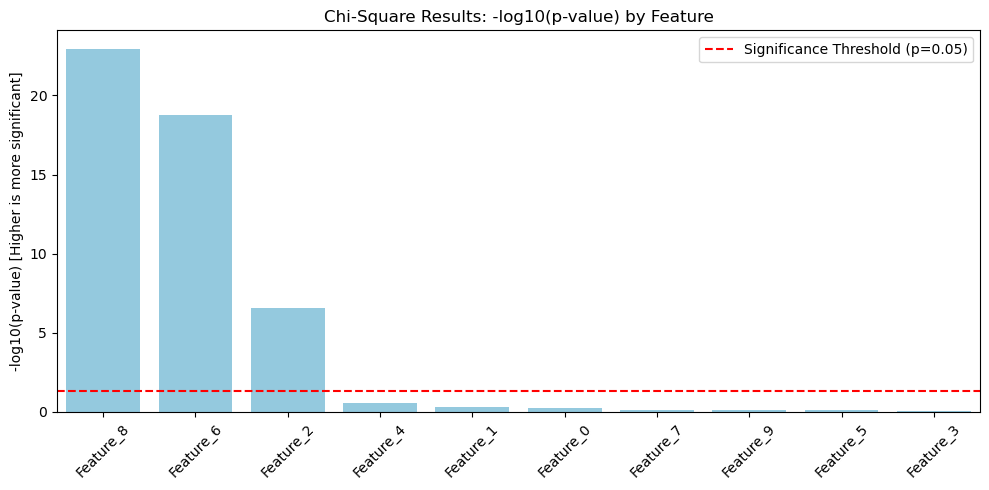

Chi-Square Significant Features: [('Feature_8', 1.0906519872314315e-23), ('Feature_6', 1.7973467902212968e-19), ('Feature_2', 2.612709782420634e-07), ('Feature_4', 0.25812202181989397), ('Feature_1', 0.49995147988504074), ('Feature_0', 0.5918293896337359), ('Feature_7', 0.7138205684045309), ('Feature_9', 0.7251467504760194), ('Feature_5', 0.809303909327746), ('Feature_3', 0.820878483771829)]


In [16]:

# 2a. Traditional Baseline 1 (Chi-Square Test)
chi_square_features = perform_traditional_chi_square(X_train, y_train)

print("Chi-Square Significant Features:", chi_square_features)


#### Logistic Regression


--- Traditional Baseline 2: Multivariate Logistic Regression ---
                           Logit Regression Results                           
Dep. Variable:                      y   No. Observations:                 4000
Model:                          Logit   Df Residuals:                     3989
Method:                           MLE   Df Model:                           10
Date:                Sun, 12 Apr 2026   Pseudo R-squ.:                 0.03352
Time:                        16:55:48   Log-Likelihood:                -2671.6
converged:                       True   LL-Null:                       -2764.3
Covariance Type:            nonrobust   LLR p-value:                 1.819e-34
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0827      0.073     -1.140      0.254      -0.225       0.060
Feature_0     -0.0636      0.071     -0.895      0.371      -0.20

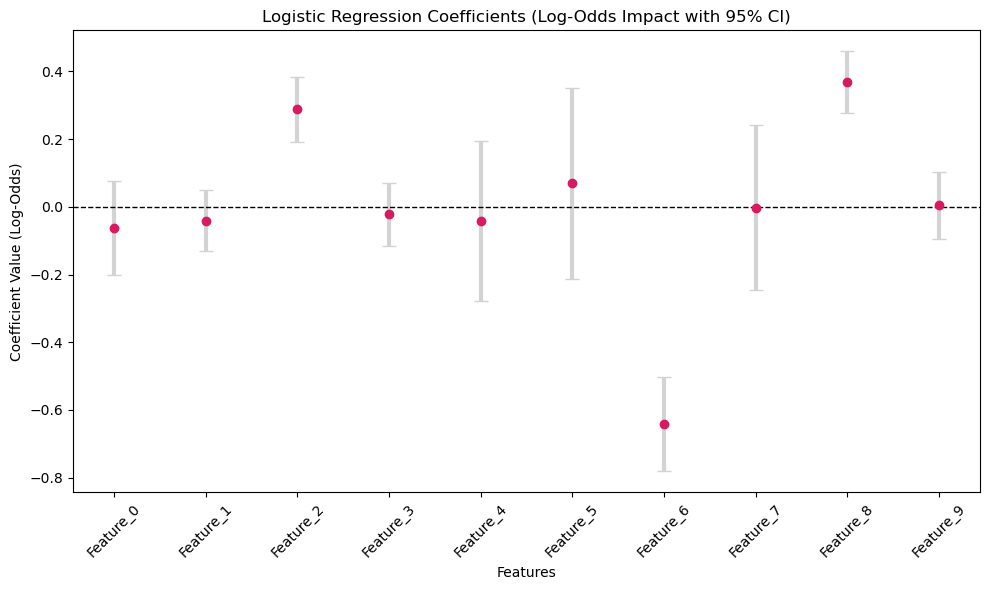

Logistic Regression Significant Features: ['Feature_2', 'Feature_6', 'Feature_8']


In [17]:

# 2b. Traditional Baseline 2 (Logistic Regression)
logistic_model, logistic_features = perform_traditional_logistic_regression(X_train, y_train)

print("Logistic Regression Significant Features:", logistic_features)


### make a simple xgboost model for test 2

In [18]:

# 3. Categorical Conversion for XGBoost
X_train_cat = X_train.astype('category')
X_test_cat = X_test.astype('category')

# 4. Machine Learning Modeling (XGBoost Classifier)
model = xgb.XGBClassifier(
    n_estimators=100, 
    max_depth=4, 
    learning_rate=0.1,
    enable_categorical=True,
    tree_method='hist',
    objective='binary:logistic',
    random_state=42
)
model.fit(X_train_cat, y_train)

# 5.1. Evaluation
evaluate_xgb_classifier(model, X_test_cat, y_test)



--- XGBoost Classifier Performance (Testing) ---
Accuracy: 0.5610
ROC AUC:  0.6019
Log Loss: 0.6720



### look at XGBoost Native Importances

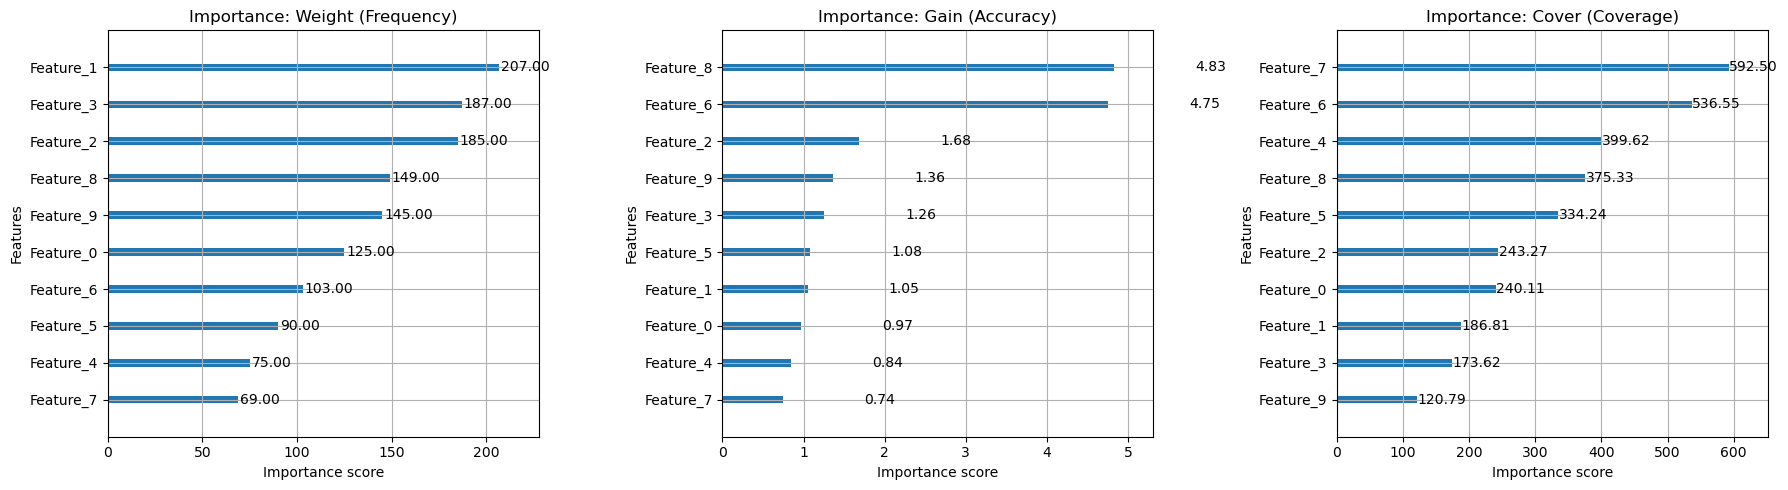

XGBoost Weight Importance: {'Feature_0': 125.0, 'Feature_1': 207.0, 'Feature_2': 185.0, 'Feature_3': 187.0, 'Feature_4': 75.0, 'Feature_5': 90.0, 'Feature_6': 103.0, 'Feature_7': 69.0, 'Feature_8': 149.0, 'Feature_9': 145.0}
XGBoost Gain Importance: {'Feature_0': 0.967355489730835, 'Feature_1': 1.050207495689392, 'Feature_2': 1.6825377941131592, 'Feature_3': 1.2575515508651733, 'Feature_4': 0.8441892862319946, 'Feature_5': 1.0781065225601196, 'Feature_6': 4.750810146331787, 'Feature_7': 0.7424587607383728, 'Feature_8': 4.826894283294678, 'Feature_9': 1.361965537071228}
XGBoost Cover Importance: {'Feature_0': 240.11288452148438, 'Feature_1': 186.80581665039062, 'Feature_2': 243.26963806152344, 'Feature_3': 173.61830139160156, 'Feature_4': 399.624755859375, 'Feature_5': 334.2352294921875, 'Feature_6': 536.5479736328125, 'Feature_7': 592.5004272460938, 'Feature_8': 375.3259582519531, 'Feature_9': 120.78834533691406}


In [19]:

# 5.2. XGBoost Importances

weight_importance, gain_importance, cover_importance = plot_all_xgb_importances(model)

print("XGBoost Weight Importance:", weight_importance)
print("XGBoost Gain Importance:", gain_importance)
print("XGBoost Cover Importance:", cover_importance)



### try to use SHAP to find the influencing inputs

In [20]:

# 6. SHAP Explainability 
print("Computing SHAP values...")
explainer = shap.TreeExplainer(model)
shap_values = explainer(X_test_cat)


Computing SHAP values...


#### individual SHAP features ranking

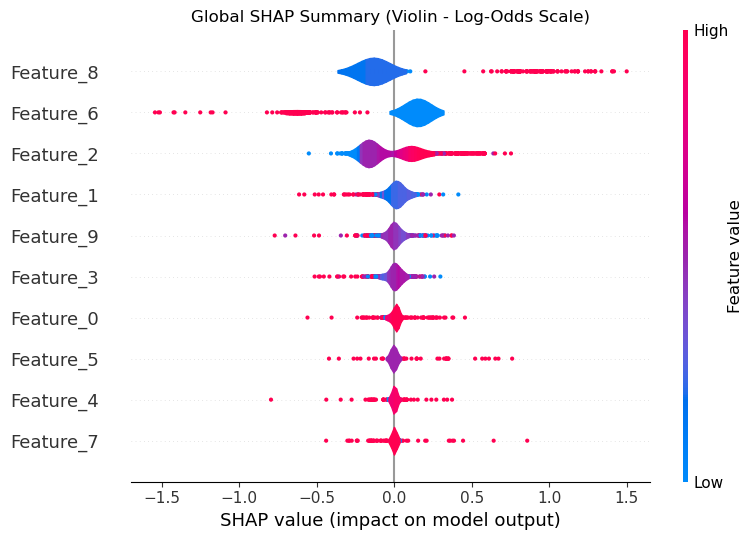

In [21]:

# Global SHAP Violin Summary
plt.title("Global SHAP Summary (Violin - Log-Odds Scale)")
shap.summary_plot(shap_values.values, X_test_cat.astype(float), plot_type="violin", show=False)
plt.show()


Generating SHAP violin grid for all features...


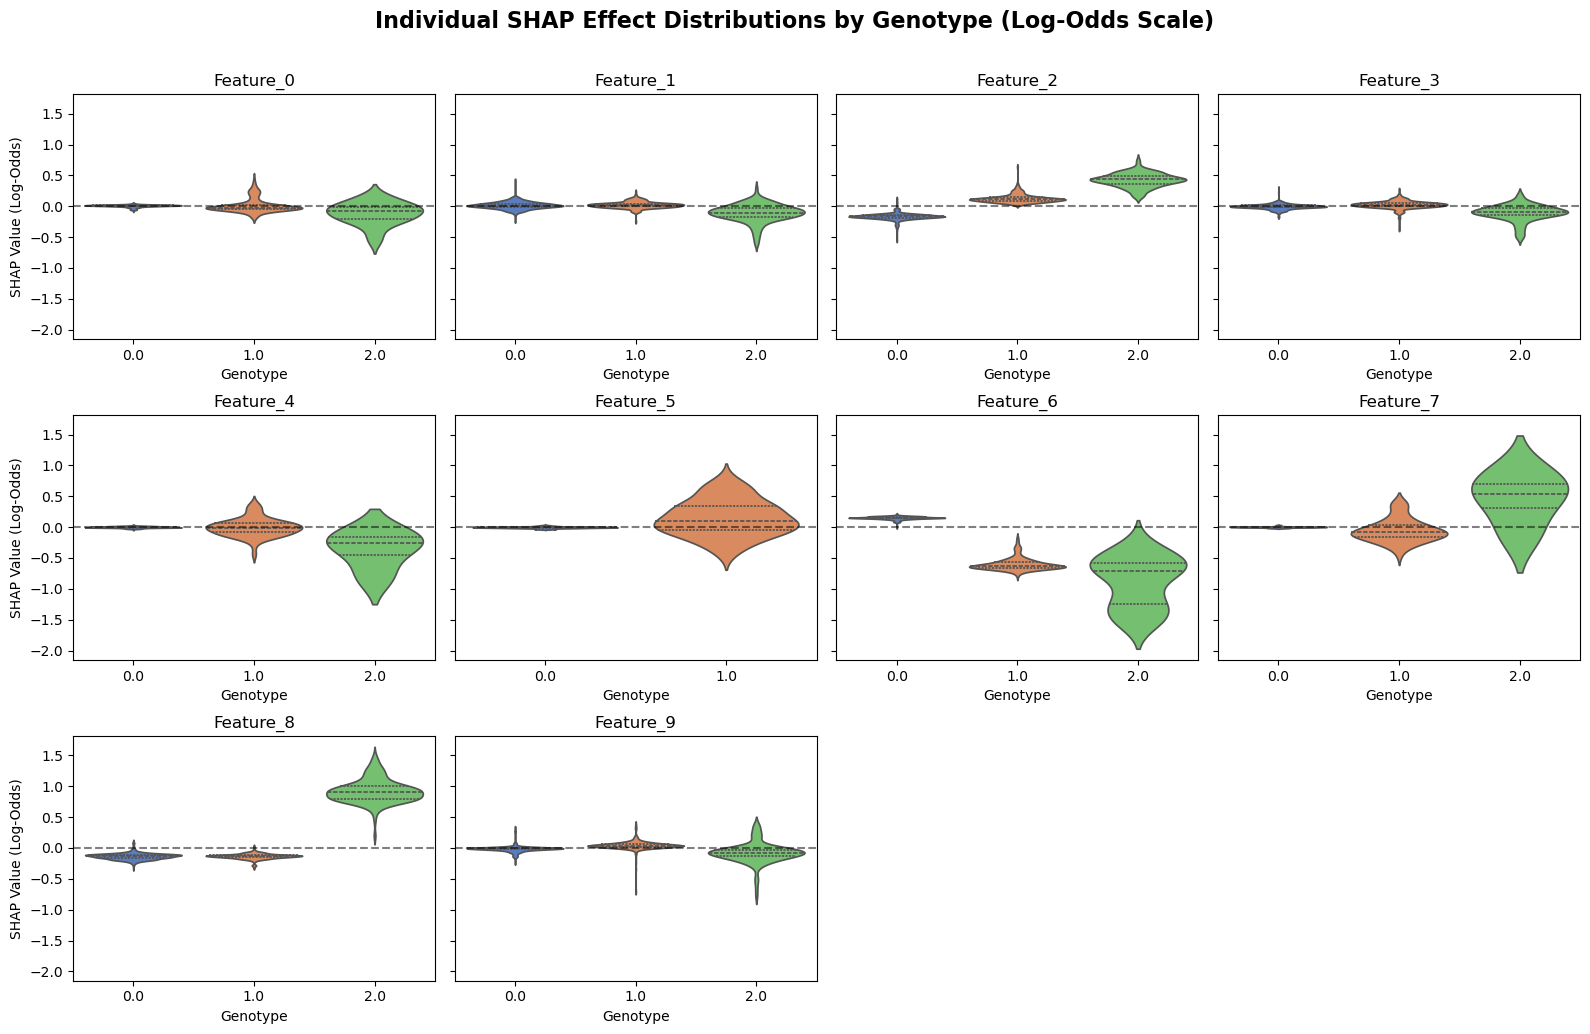

In [22]:

# 7. Individual Feature Violin Plots 
print("Generating SHAP violin grid for all features...")
plot_all_individual_shap_violins(shap_values, X_test_cat, visible_features)


#### try to look for feature interactions
we should see some now


--- Computing SHAP Interaction Values ---


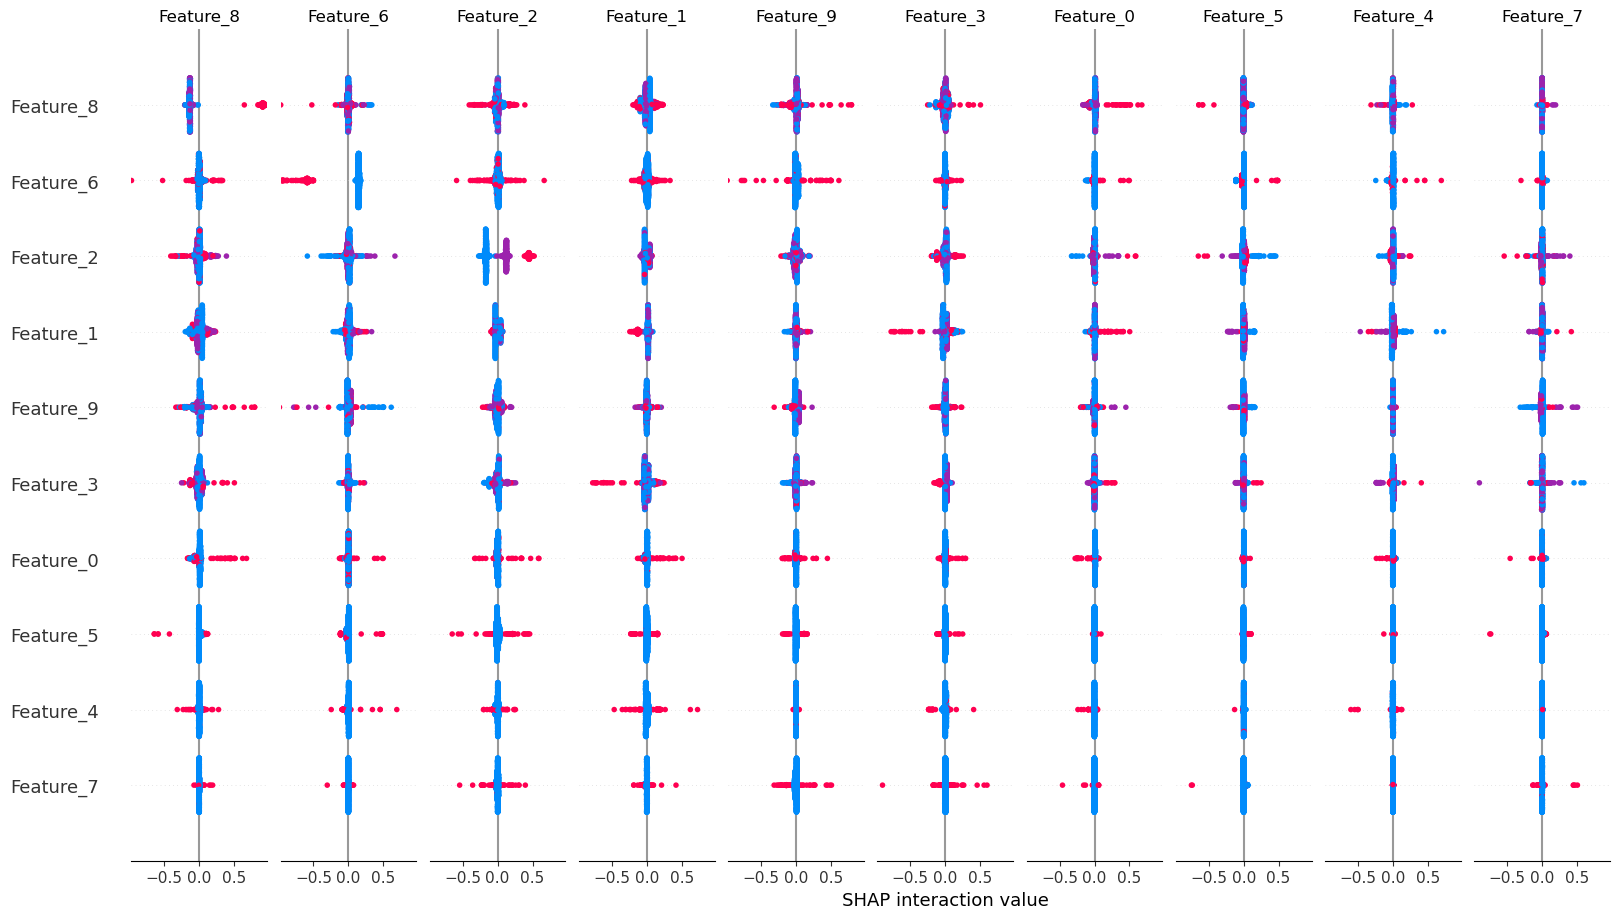


Strongest Interaction found by SHAP: Feature_1 & Feature_8
Plotting pure interaction effect for Feature_1 and Feature_8...


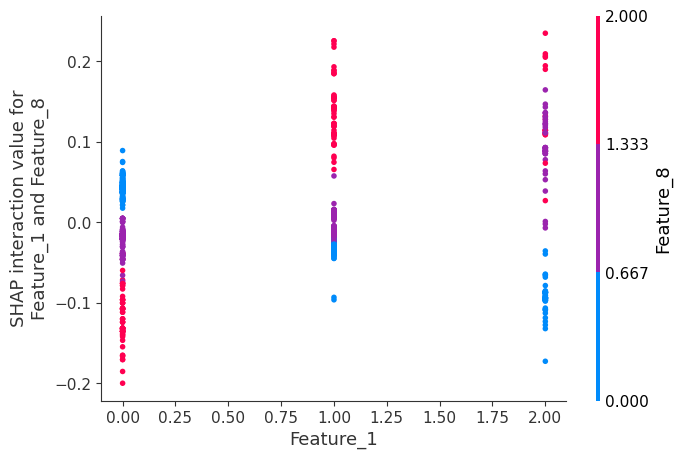


--- SHAP Interaction Feature Importance Ranking ---
Top 10 Strongest Interactions:
  Feature_1 * Feature_8: 0.050532
  Feature_1 * Feature_3: 0.046200
  Feature_8 * Feature_9: 0.039253
  Feature_0 * Feature_8: 0.035901
  Feature_2 * Feature_8: 0.032996
  Feature_6 * Feature_9: 0.032196
  Feature_1 * Feature_2: 0.031410
  Feature_2 * Feature_3: 0.030510
  Feature_3 * Feature_8: 0.030202
  Feature_2 * Feature_9: 0.027117
-------------------------------------------------

Interaction Effects:
 {'Feature_1 * Feature_8': 0.05053156986832619, 'Feature_1 * Feature_3': 0.04619990661740303, 'Feature_8 * Feature_9': 0.03925345838069916, 'Feature_0 * Feature_8': 0.035900507122278214, 'Feature_2 * Feature_8': 0.032995712012052536, 'Feature_6 * Feature_9': 0.03219565004110336, 'Feature_1 * Feature_2': 0.0314100906252861, 'Feature_2 * Feature_3': 0.030509717762470245, 'Feature_3 * Feature_8': 0.030201874673366547, 'Feature_2 * Feature_9': 0.027117138728499413, 'Feature_2 * Feature_6': 0.02622043527

In [23]:

# 8. Deep Dive: Interactions
sorted_interactions = analyze_shap_interactions(model, X_test_cat, visible_features)

print("Interaction Effects:\n", sorted_interactions)


#### SHAP summry

In [24]:

# Print numerical ranking
importance_df = print_feature_importance(shap_values, X_test_cat)

print("Ranked Features by SHAP Importance:", importance_df)


--- SHAP Feature Distribution Statistics by Genotype ---
  Feature  Global_Mean_Abs_SHAP  Option  Count  Mean_SHAP  Std_SHAP  Min_SHAP  25%_SHAP  Median_SHAP  75%_SHAP  Max_SHAP
Feature_8              0.249874     0.0    476  -0.135242  0.049740 -0.336507 -0.161632    -0.131248 -0.106190  0.103033
Feature_8              0.249874     1.0    379  -0.133947  0.042731 -0.322992 -0.150192    -0.128920 -0.118729  0.025771
Feature_8              0.249874     2.0    145   0.923152  0.188866  0.200440  0.801564     0.906063  1.004445  1.498293
Feature_6              0.242392     0.0    812   0.150929  0.023855 -0.012135  0.142158     0.151516  0.168923  0.214163
Feature_6              0.242392     1.0    163  -0.598431  0.099399 -0.786680 -0.654845    -0.634439 -0.563631 -0.173190
Feature_6              0.242392     2.0     25  -0.890739  0.406689 -1.542807 -1.251054    -0.705646 -0.584710 -0.315264
Feature_2              0.184514     0.0    556  -0.164715  0.054155 -0.550921 -0.184602    -0.16

### SHAP STATISTICAL VALIDATION

#### Permutation Test

In [25]:
shap_pvalues = compute_shap_pvalues(
    X_train=X_train, 
    y_train=y_train, 
    X_test=X_test, 
    true_shap_values=shap_values, 
    feature_names=visible_features, 
    n_permutations=50 # Increase to 100 or 500 for more robust (but slower) results
)

print("SHAP Feature P-values:", shap_pvalues)



--- Calculating Empirical SHAP p-values (Permutations: 50) ---



SHAP Empirical P-values (< 0.05 is statistically significant):
  - Feature_2: 0.0196 *
  - Feature_6: 0.0196 *
  - Feature_8: 0.0196 *
  - Feature_5: 0.1961 
  - Feature_1: 0.2941 
  - Feature_3: 0.5098 
  - Feature_9: 0.5098 
  - Feature_7: 0.5882 
  - Feature_0: 0.6275 
  - Feature_4: 0.6863 
----------------------------------------------------

SHAP Feature P-values: {'Feature_2': 0.0196078431372549, 'Feature_6': 0.0196078431372549, 'Feature_8': 0.0196078431372549, 'Feature_5': 0.19607843137254902, 'Feature_1': 0.29411764705882354, 'Feature_3': 0.5098039215686274, 'Feature_9': 0.5098039215686274, 'Feature_7': 0.5882352941176471, 'Feature_0': 0.6274509803921569, 'Feature_4': 0.6862745098039216}


#### Boruta Method

In [26]:
shadow_results = compute_shap_shadow_features(
    X_train=X_train, 
    y_train=y_train, 
    X_test=X_test, 
    feature_names=visible_features
)

print("SHAP Shadow Feature Results:", shadow_results)



--- Running SHAP Shadow Feature Analysis ---
Maximum Shadow Feature Importance (Noise Threshold): 0.0607

Shadow Feature Significance Results:
  - Feature_0: 0.0294 -> FAILED (Noise)
  - Feature_1: 0.0436 -> FAILED (Noise)
  - Feature_2: 0.1771 -> PASSED (Significant)
  - Feature_3: 0.0328 -> FAILED (Noise)
  - Feature_4: 0.0108 -> FAILED (Noise)
  - Feature_5: 0.0117 -> FAILED (Noise)
  - Feature_6: 0.2412 -> PASSED (Significant)
  - Feature_7: 0.0077 -> FAILED (Noise)
  - Feature_8: 0.2476 -> PASSED (Significant)
  - Feature_9: 0.0285 -> FAILED (Noise)
----------------------------------------------

SHAP Shadow Feature Results: {'Feature_0': False, 'Feature_1': False, 'Feature_2': True, 'Feature_3': False, 'Feature_4': False, 'Feature_5': False, 'Feature_6': True, 'Feature_7': False, 'Feature_8': True, 'Feature_9': False}


#### Confidence Intervals

In [27]:
bootstrap_results = compute_shap_bootstrapping(
    X_train=X_train, 
    y_train=y_train, 
    X_test=X_test, 
    feature_names=visible_features,
    n_bootstraps=30 # Adjust based on how long you want to wait
)

print("SHAP Bootstrapping Results:", bootstrap_results)



--- Running SHAP Bootstrapping Analysis (Iterations: 30) ---

SHAP Bootstrapped 95% Confidence Intervals:
  - Feature_8: 0.2597 (95% CI: [0.2141, 0.2979])
  - Feature_6: 0.2374 (95% CI: [0.1908, 0.2736])
  - Feature_2: 0.1751 (95% CI: [0.1192, 0.2121])
  - Feature_1: 0.0763 (95% CI: [0.0423, 0.1013])
  - Feature_3: 0.0657 (95% CI: [0.0437, 0.0952])
  - Feature_9: 0.0615 (95% CI: [0.0434, 0.0846])
  - Feature_0: 0.0453 (95% CI: [0.0281, 0.0695])
  - Feature_4: 0.0249 (95% CI: [0.0161, 0.0340])
  - Feature_5: 0.0239 (95% CI: [0.0112, 0.0413])
  - Feature_7: 0.0221 (95% CI: [0.0104, 0.0358])
-------------------------------------------------------

SHAP Bootstrapping Results: {'Feature_8': (0.25967760334412254, 0.21412175409495832, 0.29792894423007965), 'Feature_6': (0.23735548506180446, 0.19084486402571202, 0.2735582575201988), 'Feature_2': (0.17513271644711495, 0.11923631932586432, 0.21207824386656282), 'Feature_1': (0.07630931759874025, 0.04226959543302655, 0.10134310182183981), 'Featu

## test for addition of hidden features

### make example data 3

In [28]:

# 1. Generate Binary Data
X, X_hidden, y_binary, visible_features, hidden_features = generate_synthetic_classification_data(
    num_inputs=10, 
    num_samples=5000, 
    probability_range=(0.01, 0.49),
    num_contributing_features=(3, 5), 
    num_hidden_features=(1, 2), 
    weight_range=(-1.5, 1.5), 
    num_interactions=(2, 3), 
    interaction_weight_range=(-1.5, 1.5), 
    noise_std=0.5, 
    hidden_in_linear=True,           
    hidden_in_interactions=True,
)

X_train, X_test, y_train, y_test = train_test_split(X, y_binary, test_size=0.2, random_state=42)


--- Generative Model Info (Log-Odds Formulation) ---
Log-Odds (z) = 
  (-1.27 * Feature_6 [recessive]) + 
  (-1.24 * Hidden_1 [recessive]) + 
  (0.91 * Hidden_0 [dominant]) + 
  (0.69 * Feature_4 [recessive]) + 
  (0.61 * Feature_7 [additive]) + 
  (-0.53 * Feature_8 [recessive]) + 
  (-0.45 * Feature_2 [dominant]) + 
  (-1.13 * (Feature_5, Hidden_1) [xor_interference]) + 
  (-0.28 * (Feature_4, Hidden_1) [dominant_epistasis]) 
  + Noise(0, 0.5)
Probability (P) = 1 / (1 + e^-z)
Class Output = Binomial(1, P)



### make the Traditional Baselines 

#### Chi-Square Test


--- Traditional Baseline 1: Chi-Square Independence Tests ---
Significant Features (p < 0.05) [Bivariate Test]:
  - Feature_7: p-value = 4.0195e-31
  - Feature_2: p-value = 4.1667e-11
  - Feature_8: p-value = 1.2716e-03


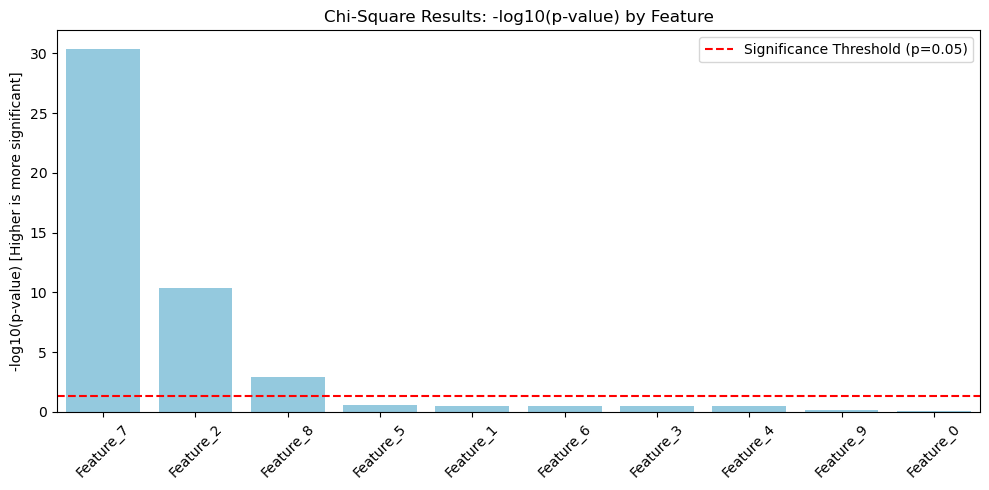

Chi-Square Significant Features: [('Feature_7', 4.019512026509013e-31), ('Feature_2', 4.166739940325841e-11), ('Feature_8', 0.0012715673940709722), ('Feature_5', 0.2502339413997259), ('Feature_1', 0.3050561109372337), ('Feature_6', 0.3302124192416938), ('Feature_3', 0.3442443315524584), ('Feature_4', 0.3471007118296423), ('Feature_9', 0.7546683293316397), ('Feature_0', 0.8304498856432235)]


In [29]:

# 2a. Traditional Baseline 1 (Chi-Square Test)
chi_square_features = perform_traditional_chi_square(X_train, y_train)

print("Chi-Square Significant Features:", chi_square_features)


#### Logistic Regression


--- Traditional Baseline 2: Multivariate Logistic Regression ---
                           Logit Regression Results                           
Dep. Variable:                      y   No. Observations:                 4000
Model:                          Logit   Df Residuals:                     3989
Method:                           MLE   Df Model:                           10
Date:                Sun, 12 Apr 2026   Pseudo R-squ.:                 0.03765
Time:                        16:56:25   Log-Likelihood:                -2638.5
converged:                       True   LL-Null:                       -2741.8
Covariance Type:            nonrobust   LLR p-value:                 7.319e-39
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.4250      0.075     -5.653      0.000      -0.572      -0.278
Feature_0      0.0141      0.051      0.276      0.782      -0.08

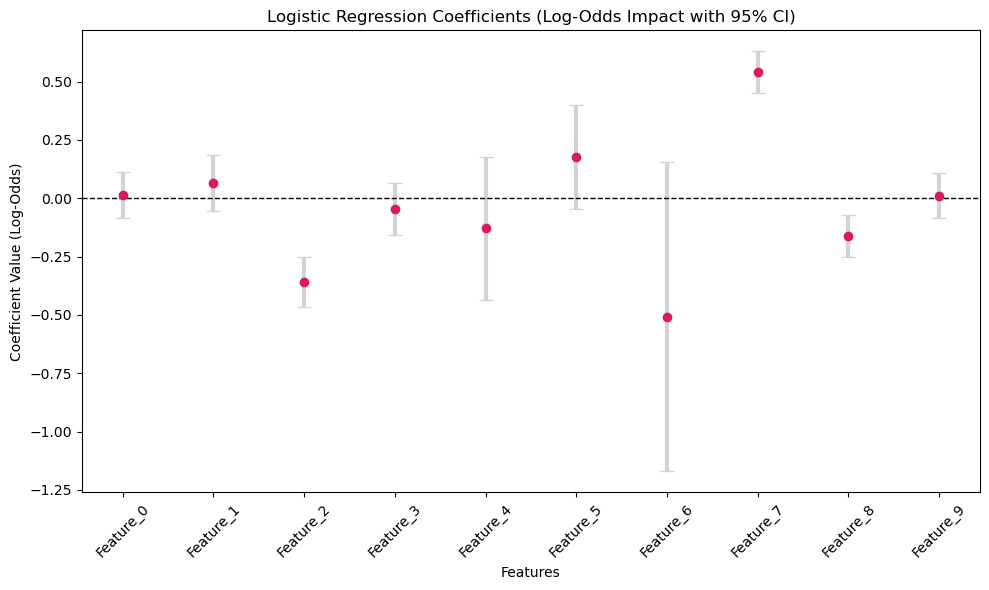

Logistic Regression Significant Features: ['Feature_2', 'Feature_7', 'Feature_8']


In [30]:

# 2b. Traditional Baseline 2 (Logistic Regression)
logistic_model, logistic_features = perform_traditional_logistic_regression(X_train, y_train)

print("Logistic Regression Significant Features:", logistic_features)


### make a simple xgboost model for test 3

In [31]:

# 3. Categorical Conversion for XGBoost
X_train_cat = X_train.astype('category')
X_test_cat = X_test.astype('category')

# 4. Machine Learning Modeling (XGBoost Classifier)
model = xgb.XGBClassifier(
    n_estimators=100, 
    max_depth=4, 
    learning_rate=0.1,
    enable_categorical=True,
    tree_method='hist',
    objective='binary:logistic',
    random_state=42
)
model.fit(X_train_cat, y_train)

# 5.1. Evaluation
evaluate_xgb_classifier(model, X_test_cat, y_test)



--- XGBoost Classifier Performance (Testing) ---
Accuracy: 0.6070
ROC AUC:  0.6302
Log Loss: 0.6720



### look at XGBoost Native Importances

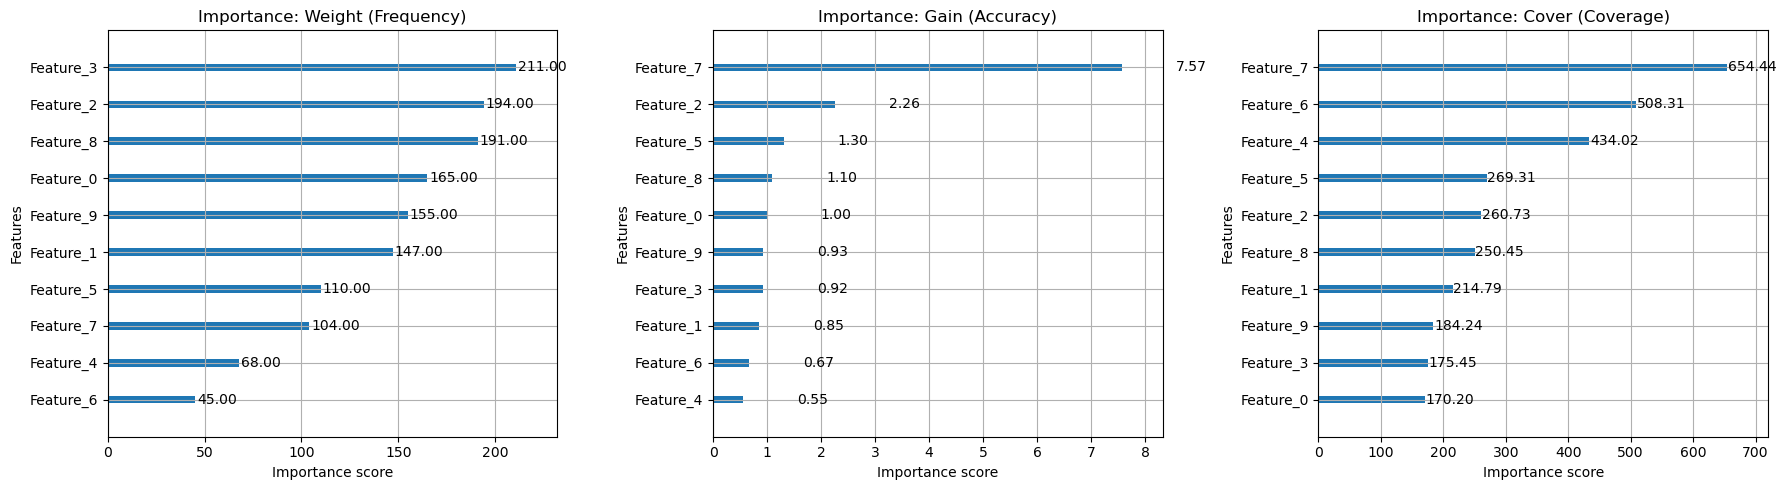

XGBoost Weight Importance: {'Feature_0': 165.0, 'Feature_1': 147.0, 'Feature_2': 194.0, 'Feature_3': 211.0, 'Feature_4': 68.0, 'Feature_5': 110.0, 'Feature_6': 45.0, 'Feature_7': 104.0, 'Feature_8': 191.0, 'Feature_9': 155.0}
XGBoost Gain Importance: {'Feature_0': 0.9953638315200806, 'Feature_1': 0.8502805829048157, 'Feature_2': 2.2612011432647705, 'Feature_3': 0.9200680255889893, 'Feature_4': 0.5525396466255188, 'Feature_5': 1.3039497137069702, 'Feature_6': 0.6722890138626099, 'Feature_7': 7.567230224609375, 'Feature_8': 1.0995235443115234, 'Feature_9': 0.9306308627128601}
XGBoost Cover Importance: {'Feature_0': 170.20401000976562, 'Feature_1': 214.78895568847656, 'Feature_2': 260.72906494140625, 'Feature_3': 175.4485321044922, 'Feature_4': 434.0203552246094, 'Feature_5': 269.30712890625, 'Feature_6': 508.3111877441406, 'Feature_7': 654.4398803710938, 'Feature_8': 250.4481964111328, 'Feature_9': 184.23854064941406}


In [32]:

# 5.2. XGBoost Importances

weight_importance, gain_importance, cover_importance = plot_all_xgb_importances(model)

print("XGBoost Weight Importance:", weight_importance)
print("XGBoost Gain Importance:", gain_importance)
print("XGBoost Cover Importance:", cover_importance)



### try to use SHAP to find the influencing inputs

In [33]:

# 6. SHAP Explainability 
print("Computing SHAP values...")
explainer = shap.TreeExplainer(model)
shap_values = explainer(X_test_cat)


Computing SHAP values...


#### individual SHAP features ranking

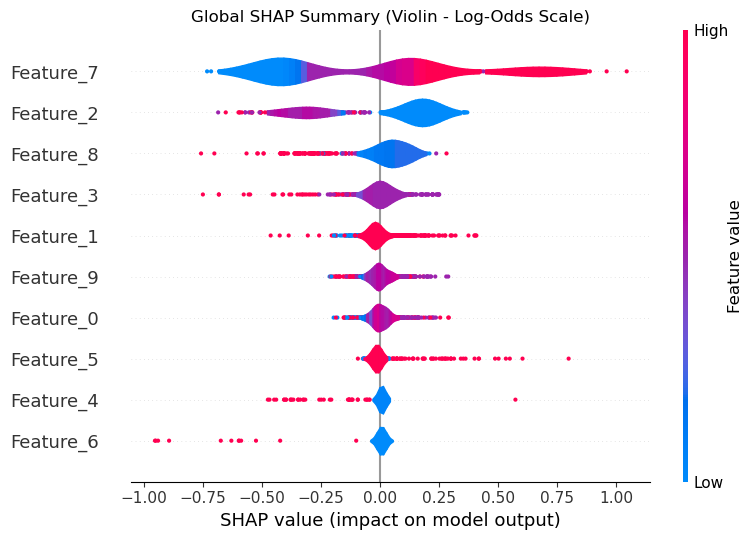

In [34]:

# Global SHAP Violin Summary
plt.title("Global SHAP Summary (Violin - Log-Odds Scale)")
shap.summary_plot(shap_values.values, X_test_cat.astype(float), plot_type="violin", show=False)
plt.show()


Generating SHAP violin grid for all features...


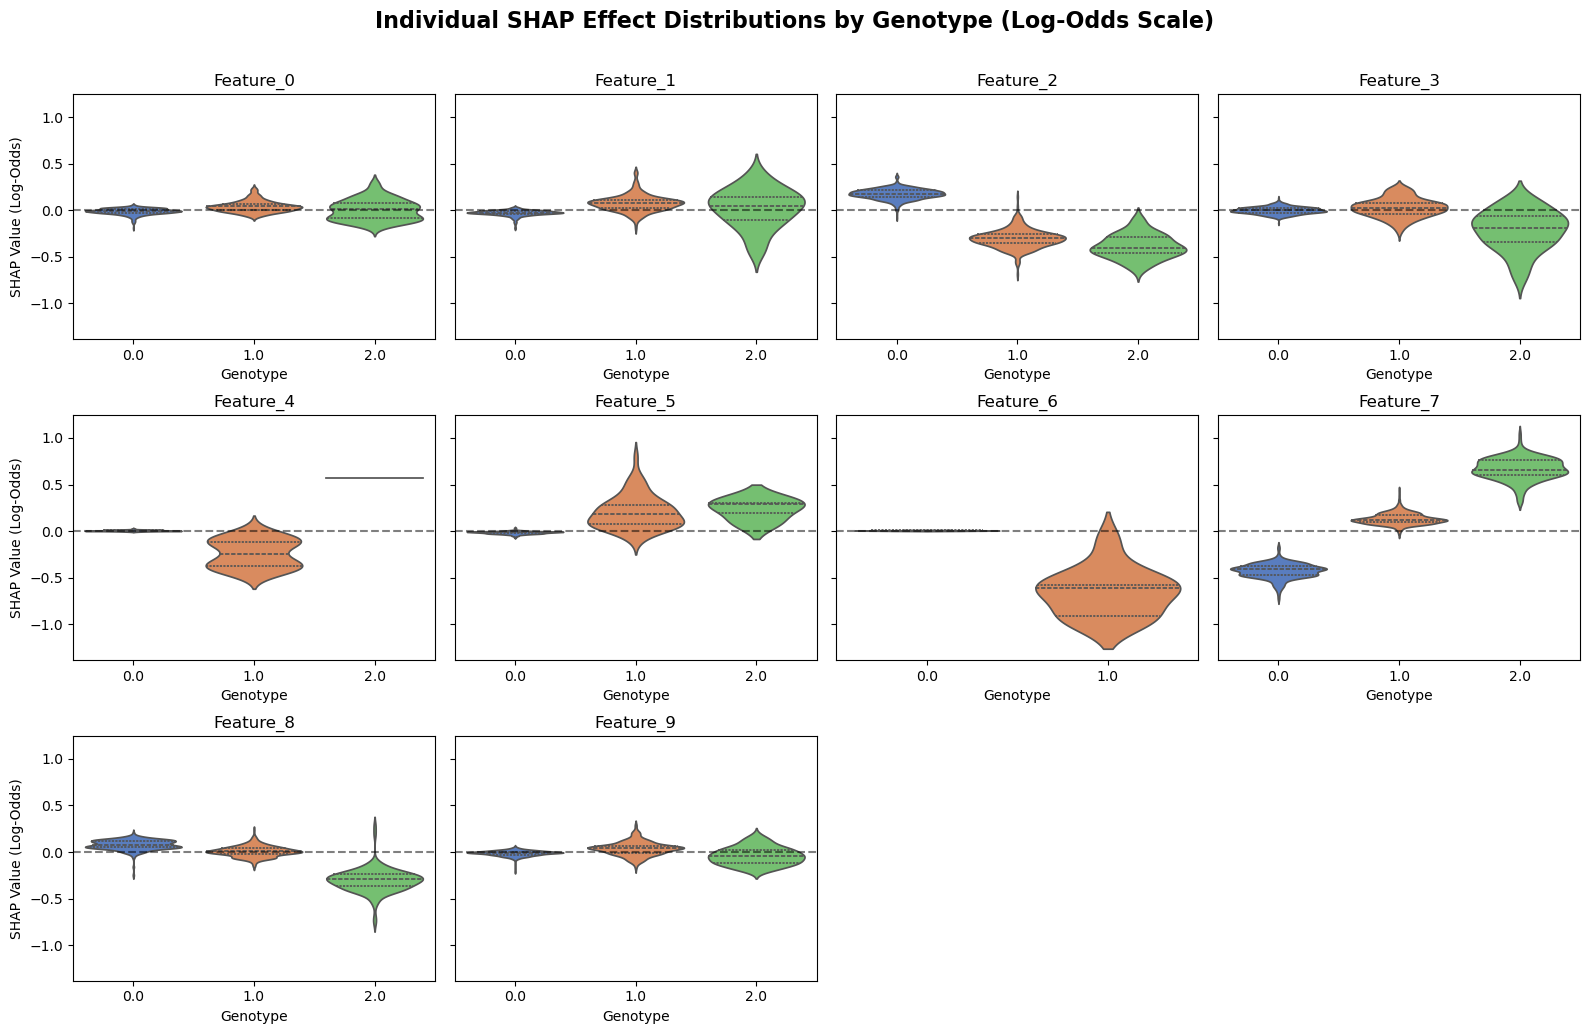

In [35]:

# 7. Individual Feature Violin Plots 
print("Generating SHAP violin grid for all features...")
plot_all_individual_shap_violins(shap_values, X_test_cat, visible_features)


#### try to look for feature interactions
we should see some now


--- Computing SHAP Interaction Values ---


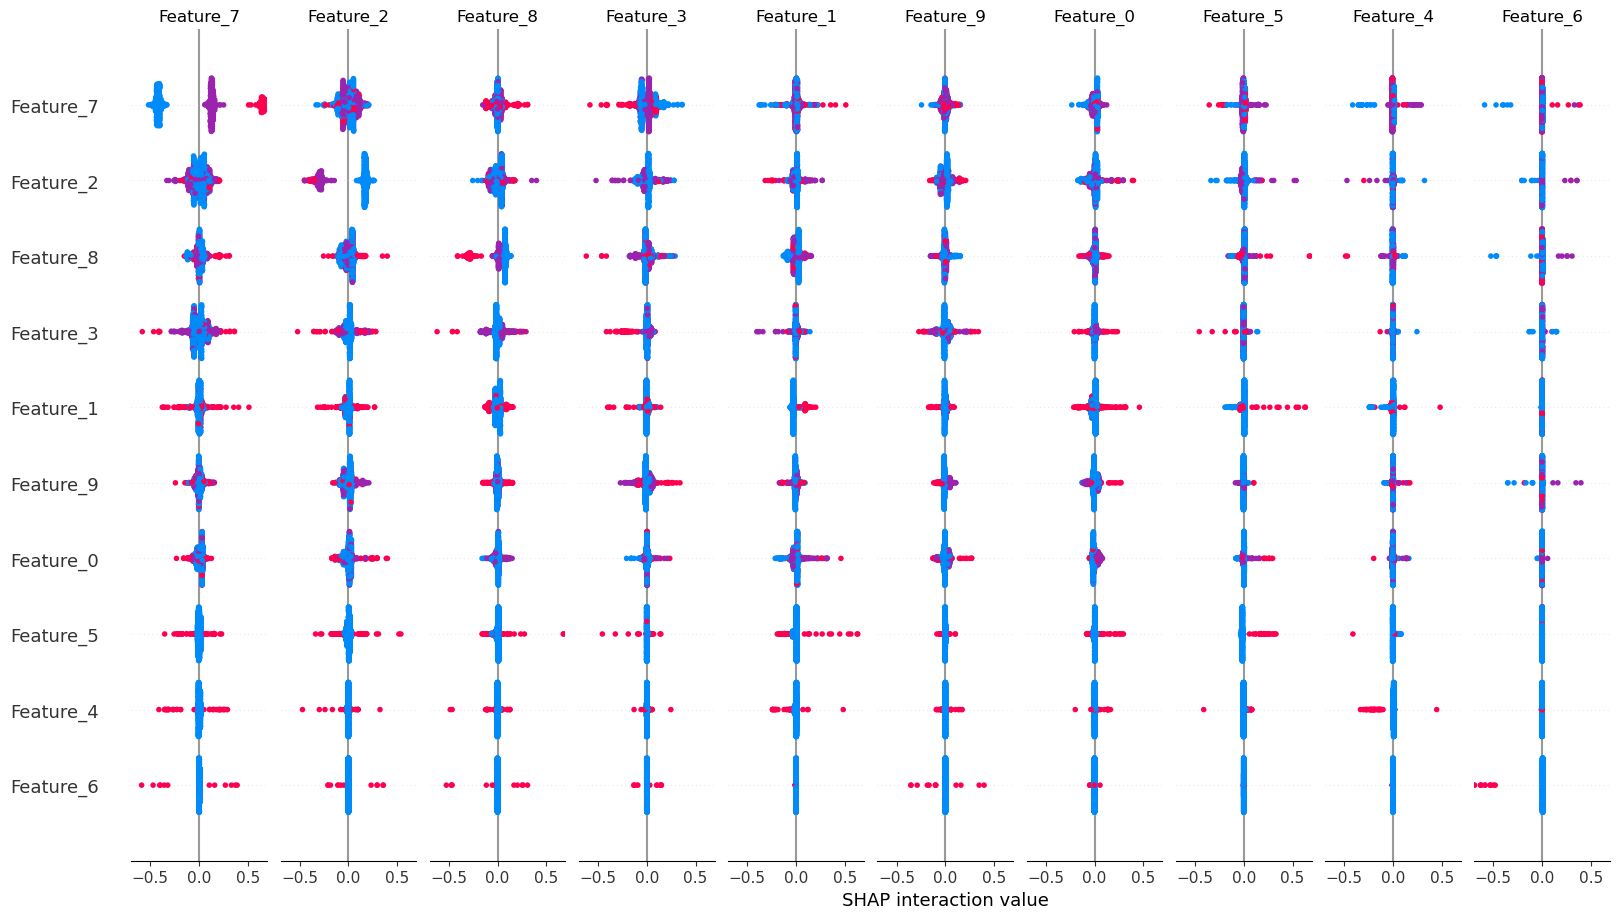


Strongest Interaction found by SHAP: Feature_3 & Feature_7
Plotting pure interaction effect for Feature_3 and Feature_7...


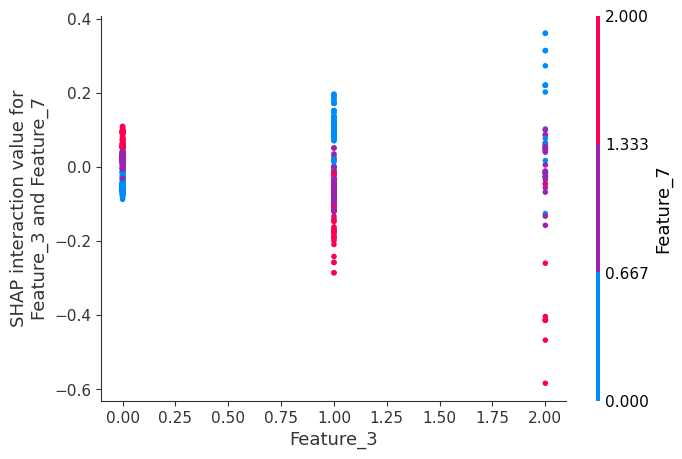


--- SHAP Interaction Feature Importance Ranking ---
Top 10 Strongest Interactions:
  Feature_3 * Feature_7: 0.062366
  Feature_2 * Feature_7: 0.058961
  Feature_2 * Feature_8: 0.047653
  Feature_2 * Feature_3: 0.045944
  Feature_3 * Feature_8: 0.041739
  Feature_3 * Feature_9: 0.038778
  Feature_2 * Feature_9: 0.036023
  Feature_1 * Feature_8: 0.035291
  Feature_0 * Feature_2: 0.033483
  Feature_7 * Feature_8: 0.031646
-------------------------------------------------

Interaction Effects:
 {'Feature_3 * Feature_7': 0.0623655766248703, 'Feature_2 * Feature_7': 0.058960843831300735, 'Feature_2 * Feature_8': 0.04765285924077034, 'Feature_2 * Feature_3': 0.045944150537252426, 'Feature_3 * Feature_8': 0.04173855856060982, 'Feature_3 * Feature_9': 0.03877823054790497, 'Feature_2 * Feature_9': 0.03602349013090134, 'Feature_1 * Feature_8': 0.035290706902742386, 'Feature_0 * Feature_2': 0.03348314017057419, 'Feature_7 * Feature_8': 0.03164629638195038, 'Feature_0 * Feature_1': 0.0306125842034

In [36]:

# 8. Deep Dive: Interactions
sorted_interactions = analyze_shap_interactions(model, X_test_cat, visible_features)

print("Interaction Effects:\n", sorted_interactions)


#### SHAP summry

In [37]:

# Print numerical ranking
importance_df = print_feature_importance(shap_values, X_test_cat)

print("Ranked Features by SHAP Importance:", importance_df)


--- SHAP Feature Distribution Statistics by Genotype ---
  Feature  Global_Mean_Abs_SHAP  Option  Count  Mean_SHAP  Std_SHAP  Min_SHAP  25%_SHAP  Median_SHAP  75%_SHAP  Max_SHAP
Feature_7              0.354982     0.0    432  -0.426891  0.078122 -0.733201 -0.472562    -0.410491 -0.376002 -0.165349
Feature_7              0.354982     1.0    391   0.133332  0.059378 -0.038006  0.093870     0.118561  0.172332  0.438061
Feature_7              0.354982     2.0    177   0.668341  0.116860  0.313041  0.604293     0.656292  0.762152  1.045323
Feature_2              0.229097     0.0    635   0.176510  0.055314 -0.081638  0.145752     0.175220  0.214711  0.369621
Feature_2              0.229097     1.0    303  -0.304838  0.099185 -0.686320 -0.354753    -0.300727 -0.259159  0.145631
Feature_2              0.229097     2.0     62  -0.387648  0.127066 -0.654116 -0.463998    -0.403480 -0.284303 -0.082042
Feature_8              0.097360     0.0    532   0.078280  0.052785 -0.256056  0.049411     0.07

### SHAP STATISTICAL VALIDATION

#### Permutation Test

In [38]:
shap_pvalues = compute_shap_pvalues(
    X_train=X_train, 
    y_train=y_train, 
    X_test=X_test, 
    true_shap_values=shap_values, 
    feature_names=visible_features, 
    n_permutations=50 # Increase to 100 or 500 for more robust (but slower) results
)

print("SHAP Feature P-values:", shap_pvalues)



--- Calculating Empirical SHAP p-values (Permutations: 50) ---

SHAP Empirical P-values (< 0.05 is statistically significant):
  - Feature_2: 0.0196 *
  - Feature_7: 0.0196 *
  - Feature_8: 0.0196 *
  - Feature_5: 0.0980 
  - Feature_6: 0.1176 
  - Feature_1: 0.1961 
  - Feature_3: 0.2549 
  - Feature_4: 0.2549 
  - Feature_0: 0.6667 
  - Feature_9: 0.7255 
----------------------------------------------------

SHAP Feature P-values: {'Feature_2': 0.0196078431372549, 'Feature_7': 0.0196078431372549, 'Feature_8': 0.0196078431372549, 'Feature_5': 0.09803921568627451, 'Feature_6': 0.11764705882352941, 'Feature_1': 0.19607843137254902, 'Feature_3': 0.2549019607843137, 'Feature_4': 0.2549019607843137, 'Feature_0': 0.6666666666666666, 'Feature_9': 0.7254901960784313}


#### Boruta Method

In [39]:
shadow_results = compute_shap_shadow_features(
    X_train=X_train, 
    y_train=y_train, 
    X_test=X_test, 
    feature_names=visible_features
)

print("SHAP Shadow Feature Results:", shadow_results)



--- Running SHAP Shadow Feature Analysis ---


Maximum Shadow Feature Importance (Noise Threshold): 0.0495

Shadow Feature Significance Results:
  - Feature_0: 0.0249 -> FAILED (Noise)
  - Feature_1: 0.0376 -> FAILED (Noise)
  - Feature_2: 0.2220 -> PASSED (Significant)
  - Feature_3: 0.0341 -> FAILED (Noise)
  - Feature_4: 0.0126 -> FAILED (Noise)
  - Feature_5: 0.0234 -> FAILED (Noise)
  - Feature_6: 0.0138 -> FAILED (Noise)
  - Feature_7: 0.3455 -> PASSED (Significant)
  - Feature_8: 0.0834 -> PASSED (Significant)
  - Feature_9: 0.0211 -> FAILED (Noise)
----------------------------------------------

SHAP Shadow Feature Results: {'Feature_0': False, 'Feature_1': False, 'Feature_2': True, 'Feature_3': False, 'Feature_4': False, 'Feature_5': False, 'Feature_6': False, 'Feature_7': True, 'Feature_8': True, 'Feature_9': False}


#### Confidence Intervals

In [40]:
bootstrap_results = compute_shap_bootstrapping(
    X_train=X_train, 
    y_train=y_train, 
    X_test=X_test, 
    feature_names=visible_features,
    n_bootstraps=30 # Adjust based on how long you want to wait
)

print("SHAP Bootstrapping Results:", bootstrap_results)



--- Running SHAP Bootstrapping Analysis (Iterations: 30) ---

SHAP Bootstrapped 95% Confidence Intervals:
  - Feature_7: 0.3652 (95% CI: [0.3207, 0.4106])
  - Feature_2: 0.2338 (95% CI: [0.1924, 0.2780])
  - Feature_8: 0.1118 (95% CI: [0.0729, 0.1504])
  - Feature_3: 0.0653 (95% CI: [0.0376, 0.0872])
  - Feature_9: 0.0621 (95% CI: [0.0379, 0.1002])
  - Feature_1: 0.0602 (95% CI: [0.0341, 0.0959])
  - Feature_0: 0.0598 (95% CI: [0.0358, 0.0914])
  - Feature_5: 0.0352 (95% CI: [0.0155, 0.0549])
  - Feature_4: 0.0218 (95% CI: [0.0080, 0.0342])
  - Feature_6: 0.0133 (95% CI: [0.0032, 0.0237])
-------------------------------------------------------

SHAP Bootstrapping Results: {'Feature_7': (0.3652349670728048, 0.32065352126955987, 0.4105639263987541), 'Feature_2': (0.23380098789930343, 0.19239956550300122, 0.27804076075553896), 'Feature_8': (0.1118090079476436, 0.07290478954091668, 0.15037329867482185), 'Feature_3': (0.06525879601637523, 0.0376155648380518, 0.08721811436116694), 'Feature_